In [6]:
# =========================
# 1. Imports & Setup
# =========================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from tensorflow.keras.datasets import mnist

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
# =========================
# 2. Load MNIST Dataset
# =========================

(X_train_full, y_train_full), (X_test_img, y_test) = mnist.load_data()

print("Training images:", X_train_full.shape)
print("Training labels:", y_train_full.shape)
print("Test images:", X_test_img.shape)
print("Test labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


In [8]:
# =========================
# 3. Normalize & Flatten
# =========================

X_train_full = X_train_full.astype("float32") / 255.0
X_test_img = X_test_img.astype("float32") / 255.0

X_train_flat = X_train_full.reshape(X_train_full.shape[0], -1)
X_test_flat = X_test_img.reshape(X_test_img.shape[0], -1)

print("Flattened train:", X_train_flat.shape)
print("Flattened test:", X_test_flat.shape)

Flattened train: (60000, 784)
Flattened test: (10000, 784)


In [9]:
# =========================
# 4. Train / Validation Split
# =========================

X_train, X_val, y_train, y_val = train_test_split(
    X_train_flat,
    y_train_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

X_train_img, X_val_img, y_train_img, y_val_img = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print("Train flat:", X_train.shape)
print("Validation flat:", X_val.shape)
print("Train image:", X_train_img.shape)
print("Validation image:", X_val_img.shape)

Train flat: (48000, 784)
Validation flat: (12000, 784)
Train image: (48000, 28, 28)
Validation image: (12000, 28, 28)


In [10]:
# =========================
# 5. Feature Scaling
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_flat)

print("Scaling completed.")

Scaling completed.


In [4]:
# =========================
# 6. Evaluation Function
# =========================

def evaluate_model(model, X_data, y_true, dataset_name="Dataset"):
    y_pred = model.predict(X_data)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro")
    rec = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\nEvaluation on {dataset_name}")
    print("-" * 45)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    }

Iteration 0: Loss = 9.0784
Iteration 500: Loss = 0.5979
Iteration 1000: Loss = 0.5147

Evaluation on Validation - Linear SVM From Scratch
---------------------------------------------
Accuracy : 0.9077
Precision: 0.9073
Recall   : 0.9067
F1-score : 0.9067

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1185
           1       0.92      0.96      0.94      1348
           2       0.92      0.87      0.89      1192
           3       0.90      0.87      0.89      1226
           4       0.90      0.93      0.91      1168
           5       0.89      0.86      0.87      1084
           6       0.94      0.94      0.94      1184
           7       0.93      0.92      0.92      1253
           8       0.86      0.86      0.86      1170
           9       0.88      0.90      0.89      1190

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg    

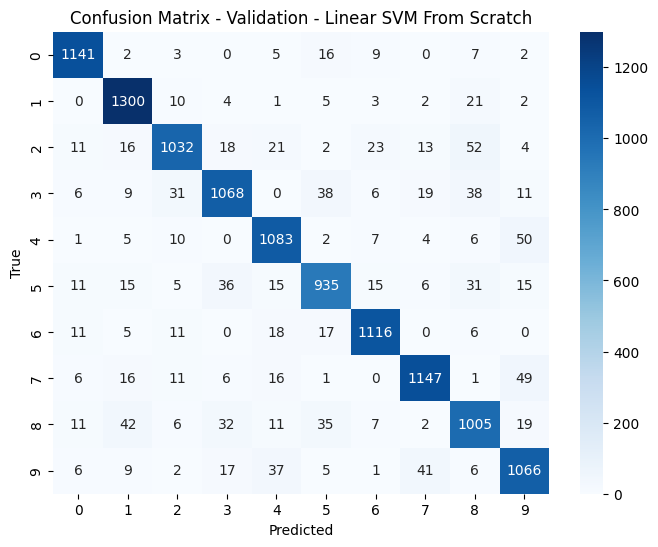

{'Accuracy': 0.90775,
 'Precision': 0.9073085793052446,
 'Recall': 0.9066673744982587,
 'F1-score': 0.9067476291896612}

In [9]:
# Import the class from your Python file
from LinearSVMFromScratch import LinearSVMFromScratch

# If you edited the file and Jupyter cached the old version, uncomment:
# import importlib
# import LinearSVMFromScratch
# importlib.reload(LinearSVMFromScratch)
# from LinearSVMFromScratch import LinearSVMFromScratch

# =========================
# 14. Train Linear SVM From Scratch
# =========================

svm_model = LinearSVMFromScratch(
    learning_rate=0.001,
    num_iterations=1500,
    reg_strength=0.001
)

# Train model
svm_model.fit(X_train_scaled, y_train)

# Evaluate on validation set
svm_val_results = evaluate_model(
    svm_model,
    X_val_scaled,
    y_val,
    dataset_name="Validation - Linear SVM From Scratch"
)

# Show results
svm_val_results

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from LinearSVMFromScratch import LinearSVMFromScratch

# =========================
# SVM Hyperparameter Tuning with Cross-Validation
# =========================

def cross_validate_svm(X, y, learning_rates, reg_values, k_folds=3):
    # Convert to NumPy arrays to avoid indexing issues
    X = np.asarray(X)
    y = np.asarray(y)

    skf = StratifiedKFold(
        n_splits=k_folds,
        shuffle=True,
        random_state=42
    )

    results = []

    for lr in learning_rates:
        for reg in reg_values:
            fold_scores = []

            print(f"Testing learning_rate={lr}, reg_strength={reg}")

            for train_idx, val_idx in skf.split(X, y):
                X_tr, X_va = X[train_idx], X[val_idx]
                y_tr, y_va = y[train_idx], y[val_idx]

                model = LinearSVMFromScratch(
                    learning_rate=lr,
                    num_iterations=500,
                    reg_strength=reg
                )

                model.fit(X_tr, y_tr)
                y_pred = model.predict(X_va)

                score = f1_score(y_va, y_pred, average="macro")
                fold_scores.append(score)

            results.append({
                "Learning Rate": lr,
                "Regularization": reg,
                "Mean CV F1-score": np.mean(fold_scores),
                "Std CV F1-score": np.std(fold_scores)
            })

    return pd.DataFrame(results).sort_values(
        by="Mean CV F1-score",
        ascending=False
    ).reset_index(drop=True)

# =========================
# Run Cross Validation
# =========================

cv_subset_size = 10000

X_cv = np.asarray(X_train_scaled[:cv_subset_size])
y_cv = np.asarray(y_train[:cv_subset_size])

svm_cv_results = cross_validate_svm(
    X_cv,
    y_cv,
    learning_rates=[0.0005, 0.001],
    reg_values=[0.0001, 0.001, 0.01],
    k_folds=3
)

print(svm_cv_results)

Testing learning_rate=0.0005, reg_strength=0.0001
Iteration 0: Loss = 9.0834
Iteration 0: Loss = 9.0041
Iteration 0: Loss = 9.0079
Testing learning_rate=0.0005, reg_strength=0.001
Iteration 0: Loss = 8.9813
Iteration 0: Loss = 9.0219
Iteration 0: Loss = 8.9870
Testing learning_rate=0.0005, reg_strength=0.01
Iteration 0: Loss = 8.9902
Iteration 0: Loss = 8.9926
Iteration 0: Loss = 9.0032
Testing learning_rate=0.001, reg_strength=0.0001
Iteration 0: Loss = 8.9436
Iteration 0: Loss = 8.9886
Iteration 0: Loss = 8.9958
Testing learning_rate=0.001, reg_strength=0.001
Iteration 0: Loss = 9.0302
Iteration 0: Loss = 9.0299
Iteration 0: Loss = 8.9723
Testing learning_rate=0.001, reg_strength=0.01
Iteration 0: Loss = 9.0362
Iteration 0: Loss = 9.0241
Iteration 0: Loss = 8.9788
   Learning Rate  Regularization  Mean CV F1-score  Std CV F1-score
0         0.0010          0.0010          0.882499         0.005985
1         0.0010          0.0001          0.881870         0.006363
2         0.0010   